## Import Libraries

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import confusion_matrix,classification_report

## Load Dataset

In [29]:
df = pd.read_csv('synthetic_healthcare_appointment_no_show.csv')
df

,appointment_id,patient_id,age,gender,city,neighborhood,scheduled_day,appointment_day,waiting_days,appointment_hour,...,temperature_celsius,rainy_day,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show_probability,no_show
0,APT-100000,PAT-25795,42,Female,Almere,East,2024-07-10,2024-07-14,4,8,...,15.3,0,Employed,Secondary,Middle,Single,0,6.9,0.0319,0
1,APT-100001,PAT-10860,9,Male,Groningen,West,2024-01-21,2024-02-07,17,12,...,13.9,0,Retired,Secondary,Middle,Married,1,4.7,0.0559,0
2,APT-100002,PAT-86820,27,Female,Utrecht,East,2025-09-06,2025-09-08,2,14,...,3.5,0,Employed,Secondary,Middle,Single,2,9.5,0.0201,0
3,APT-100003,PAT-64886,0,Female,The Hague,Rural,2024-01-24,2024-02-04,11,10,...,18.5,0,Unemployed,Secondary,Lower-Middle,Divorced,0,5.8,0.0627,1
4,APT-100004,PAT-16265,39,Male,Almere,Suburban,2025-03-27,2025-04-13,17,10,...,1.8,0,Student,NaN,NaN,Divorced,0,NaN,0.0792,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,APT-149995,PAT-77722,18,Male,Rotterdam,East,2025-11-26,2025-12-10,14,13,...,21.0,0,Student,Vocational,Middle,Single,0,10.0,0.0331,0
49996,APT-149996,PAT-54279,10,Male,Eindhoven,North,2024-02-05,2024-02-19,14,8,...,8.7,0,Employed,Vocational,Upper-Middle,Married,2,7.8,0.0390,1
49997,APT-149997,PAT-19398,27,Male,Amsterdam,Suburban,2025-05-18,2025-06-18,31,14,...,12.8,0,Employed,Vocational,Middle,Single,2,3.5,0.1165,0
49998,APT-149998,PAT-71140,41,Male,Utrecht,North,2024-06-04,2024-07-25,51,12,...,33.0,1,Unemployed,Vocational,Middle,Married,0,7.5,0.2014,0


## Exploratory Data Analysis (EDA)

In [30]:
df.shape

(50000, 39)

In [31]:
df.head()

,appointment_id,patient_id,age,gender,city,neighborhood,scheduled_day,appointment_day,waiting_days,appointment_hour,...,temperature_celsius,rainy_day,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show_probability,no_show
0,APT-100000,PAT-25795,42,Female,Almere,East,2024-07-10,2024-07-14,4,8,...,15.3,0,Employed,Secondary,Middle,Single,0,6.9,0.0319,0
1,APT-100001,PAT-10860,9,Male,Groningen,West,2024-01-21,2024-02-07,17,12,...,13.9,0,Retired,Secondary,Middle,Married,1,4.7,0.0559,0
2,APT-100002,PAT-86820,27,Female,Utrecht,East,2025-09-06,2025-09-08,2,14,...,3.5,0,Employed,Secondary,Middle,Single,2,9.5,0.0201,0
3,APT-100003,PAT-64886,0,Female,The Hague,Rural,2024-01-24,2024-02-04,11,10,...,18.5,0,Unemployed,Secondary,Lower-Middle,Divorced,0,5.8,0.0627,1
4,APT-100004,PAT-16265,39,Male,Almere,Suburban,2025-03-27,2025-04-13,17,10,...,1.8,0,Student,NaN,NaN,Divorced,0,NaN,0.0792,1


In [32]:
df.describe()

,age,waiting_days,appointment_hour,month,sms_received,reminder_calls,previous_appointments,previous_no_shows,no_show_rate,distance_km,...,hypertension,diabetes,alcoholism,disability,temperature_celsius,rainy_day,children_count,patient_satisfaction_score,no_show_probability,no_show
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49000.000000,50000.000000,50000.000000
mean,41.616100,12.706420,12.344140,6.538660,0.721700,0.896920,4.987940,0.83086,0.165727,7.978977,...,0.316120,0.215900,0.089380,0.067600,14.022894,0.340180,1.303680,7.161353,0.081802,0.082760
std,21.237004,8.914165,2.978437,3.451415,0.448166,0.868464,2.237967,1.12271,0.220794,5.667220,...,0.464965,0.411449,0.285294,0.251061,7.931375,0.473774,1.318747,1.702779,0.075970,0.275522
min,0.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.200000,...,0.000000,0.000000,0.000000,0.000000,-8.000000,0.000000,0.000000,1.000000,0.002200,0.000000
25%,27.000000,6.000000,10.000000,4.000000,0.000000,0.000000,3.000000,0.00000,0.000000,3.830000,...,0.000000,0.000000,0.000000,0.000000,8.600000,0.000000,0.000000,6.000000,0.033200,0.000000
50%,41.000000,11.000000,12.000000,7.000000,1.000000,1.000000,5.000000,0.00000,0.000000,6.690000,...,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,1.000000,7.200000,0.058000,0.000000
75%,56.000000,17.000000,15.000000,10.000000,1.000000,1.000000,6.000000,1.00000,0.286000,10.720000,...,1.000000,0.000000,0.000000,0.000000,19.400000,1.000000,2.000000,8.400000,0.102400,0.000000
max,95.000000,90.000000,18.000000,12.000000,1.000000,3.000000,16.000000,10.00000,1.000000,60.000000,...,1.000000,1.000000,1.000000,1.000000,36.000000,1.000000,5.000000,10.000000,0.814700,1.000000


In [33]:
df.describe(include='object')

,appointment_id,patient_id,gender,city,neighborhood,scheduled_day,appointment_day,day_of_week,transportation_type,insurance_type,appointment_type,doctor_specialty,clinic_type,weather_condition,employment_status,education_level,income_level,marital_status
count,50000,50000,50000,50000,50000,50000,50000,50000,48750,49250,50000,50000,50000,50000,50000,48500,48000,50000
unique,50000,38312,3,8,7,772,730,7,5,4,6,9,4,5,5,6,5,4
top,APT-149999,PAT-10645,Female,Amsterdam,Suburban,2024-08-28,2024-12-24,Tuesday,Car,Public,Consultation,General Practice,Public Hospital,Sunny,Employed,Secondary,Middle,Married
freq,1,7,26119,8940,9081,92,93,7285,17288,25717,15041,15931,20963,17027,23166,13425,16265,21612


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              50000 non-null  object 
 1   patient_id                  50000 non-null  object 
 2   age                         50000 non-null  int64  
 3   gender                      50000 non-null  object 
 4   city                        50000 non-null  object 
 5   neighborhood                50000 non-null  object 
 6   scheduled_day               50000 non-null  object 
 7   appointment_day             50000 non-null  object 
 8   waiting_days                50000 non-null  int64  
 9   appointment_hour            50000 non-null  int64  
 10  day_of_week                 50000 non-null  object 
 11  month                       50000 non-null  int64  
 12  sms_received                50000 non-null  int64  
 13  reminder_calls              500

In [35]:
df['no_show'].value_counts()

no_show
0    45862
1     4138
Name: count, dtype: int64

### Missing & Duplicate Values

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isna().sum()[df.isna().sum() > 0]

transportation_type           1250
insurance_type                 750
education_level               1500
income_level                  2000
patient_satisfaction_score    1000
dtype: int64

In [38]:
df.isna().sum()[df.isna().sum() > 0]*100/df.shape[0]

transportation_type           2.5
insurance_type                1.5
education_level               3.0
income_level                  4.0
patient_satisfaction_score    2.0
dtype: float64

In [39]:
df.dropna(subset=['income_level'],inplace=True)

### Correlation

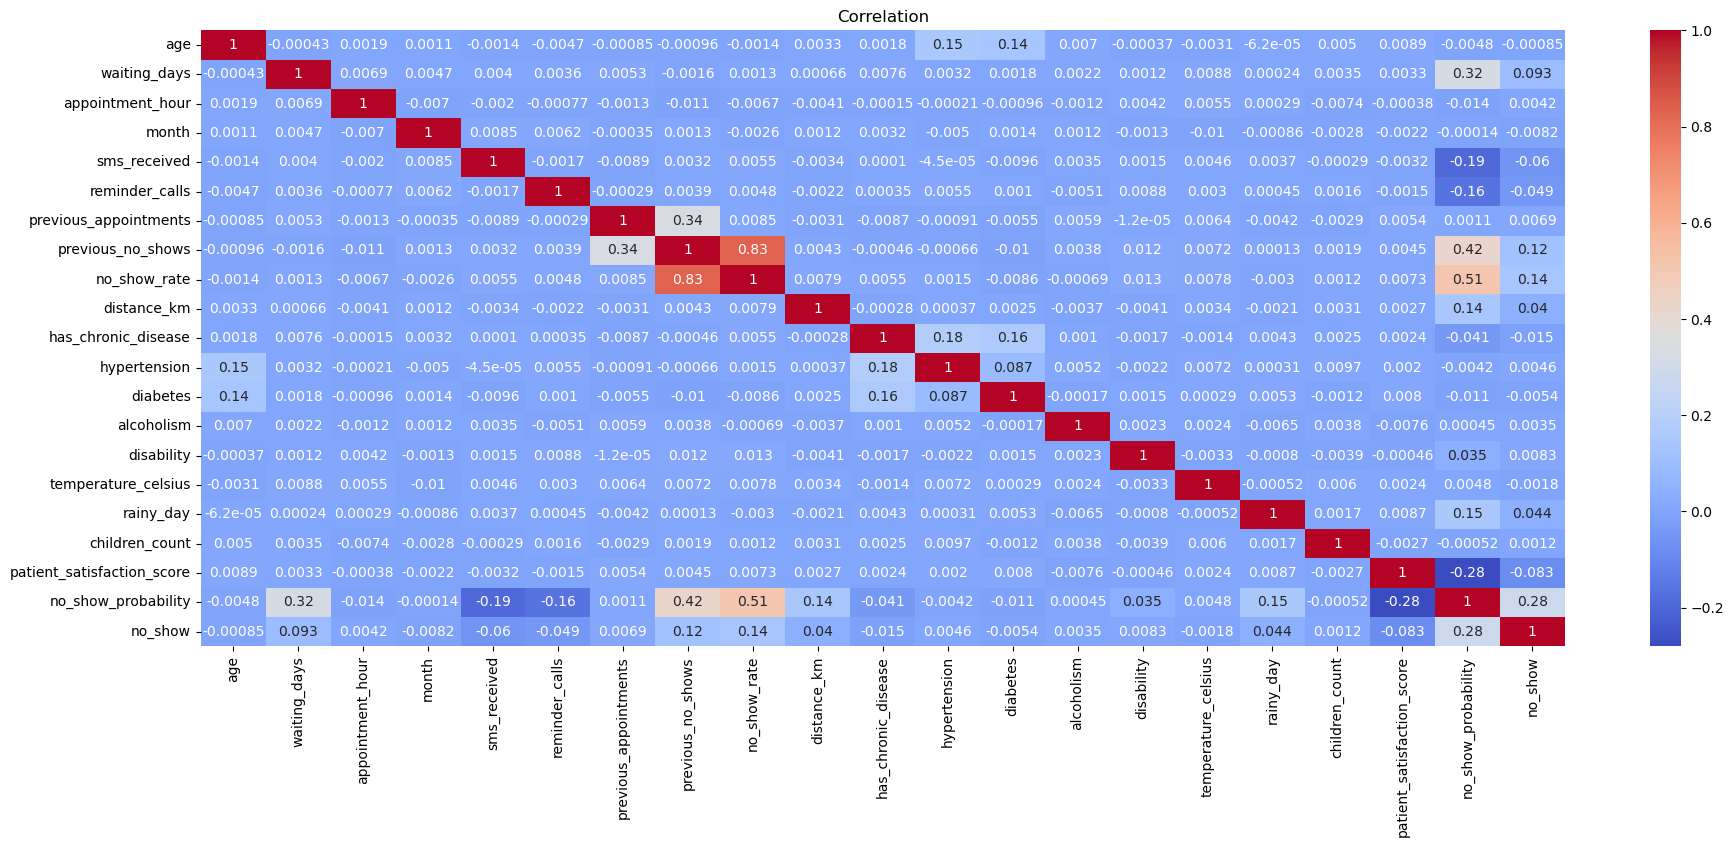

In [44]:
plt.figure(figsize=(22,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

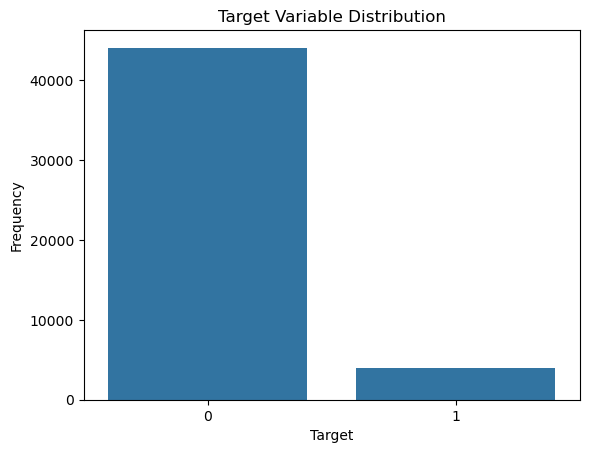

In [48]:
sns.countplot(x = df["no_show"])
plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()

## Data Preprocessing

In [53]:
df.select_dtypes(include='object').apply(lambda x: x.unique())

appointment_id         [APT-100000, APT-100001, APT-100002, APT-10000...
patient_id             [PAT-25795, PAT-10860, PAT-86820, PAT-64886, P...
gender                                             [Female, Male, Other]
city                   [Almere, Groningen, Utrecht, The Hague, Eindho...
neighborhood           [East, West, Rural, North, Suburban, Central, ...
scheduled_day          [2024-07-10, 2024-01-21, 2025-09-06, 2024-01-2...
appointment_day        [2024-07-14, 2024-02-07, 2025-09-08, 2024-02-0...
day_of_week            [Sunday, Wednesday, Monday, Saturday, Tuesday,...
transportation_type         [Public Transport, Taxi, Car, Bike, Walking]
insurance_type                       [Public, Uninsured, Private, Mixed]
appointment_type       [Diagnostic Test, Follow-up, Consultation, Rou...
doctor_specialty       [General Practice, Endocrinology, Neurology, P...
clinic_type            [Private Hospital, Public Hospital, Community ...
weather_condition                  [Sunny, Cloudy, 

In [54]:
df.select_dtypes(include='object').nunique()

appointment_id         48000
patient_id             37134
gender                     3
city                       8
neighborhood               7
scheduled_day            772
appointment_day          730
day_of_week                7
transportation_type        5
insurance_type             4
appointment_type           6
doctor_specialty           9
clinic_type                4
weather_condition          5
employment_status          5
education_level            6
income_level               5
marital_status             4
dtype: int64

In [55]:
df.drop(columns=['patient_id', 'appointment_id', 'scheduled_day', 'appointment_day'], inplace=True)

In [56]:
df.select_dtypes(include='object').nunique()

gender                 3
city                   8
neighborhood           7
day_of_week            7
transportation_type    5
insurance_type         4
appointment_type       6
doctor_specialty       9
clinic_type            4
weather_condition      5
employment_status      5
education_level        6
income_level           5
marital_status         4
dtype: int64

In [58]:
df["education_level"].value_counts()

education_level
Secondary     13281
Vocational    11577
Bachelor      10945
Primary        5862
Master         5328
PhD            1007
Name: count, dtype: int64

In [ ]:
education_mapping = {
    'Primary': 0,
    'Secondary': 1,
    'Vocational': 2,
    'Bachelor': 3,
    'Master': 4,
    'PhD': 5
}

df['education_level'] = df['education_level'].map(education_mapping)

In [59]:
df["income_level"].value_counts()

income_level
Middle          16265
Lower-Middle    11583
Low              8680
Upper-Middle     8664
High             2808
Name: count, dtype: int64

In [60]:
income_mapping = {
    'Low': 0,
    'Lower-Middle': 1,
    'Middle': 2,
    'Upper-Middle': 3,
    'High': 4
}

df['income_level'] = df['income_level'].map(income_mapping)

In [57]:
df["employment_status"].value_counts()

employment_status
Employed         22259
Retired           8574
Unemployed        6620
Student           5862
Self-employed     4685
Name: count, dtype: int64

In [61]:
df.select_dtypes(include='object').apply(lambda x: x.unique())

gender                                             [Female, Male, Other]
city                   [Almere, Groningen, Utrecht, The Hague, Eindho...
neighborhood           [East, West, Rural, North, Suburban, Central, ...
day_of_week            [Sunday, Wednesday, Monday, Saturday, Tuesday,...
transportation_type         [Public Transport, Taxi, Car, Bike, Walking]
insurance_type                       [Public, Uninsured, Private, Mixed]
appointment_type       [Diagnostic Test, Follow-up, Consultation, Rou...
doctor_specialty       [General Practice, Endocrinology, Neurology, P...
clinic_type            [Private Hospital, Public Hospital, Community ...
weather_condition                  [Sunny, Cloudy, Rainy, Stormy, Snowy]
employment_status      [Employed, Retired, Unemployed, Student, Self-...
education_level        [Secondary, Bachelor, Vocational, Primary, Mas...
marital_status                      [Single, Married, Divorced, Widowed]
dtype: object

In [62]:
df.select_dtypes(include='object').nunique()

gender                 3
city                   8
neighborhood           7
day_of_week            7
transportation_type    5
insurance_type         4
appointment_type       6
doctor_specialty       9
clinic_type            4
weather_condition      5
employment_status      5
education_level        6
marital_status         4
dtype: int64

In [63]:
df.drop(columns=['city','neighborhood','day_of_week', 'transportation_type','weather_condition',"employment_status","education_level","marital_status"], inplace=True)

In [67]:
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)

## Target and Features

In [68]:
X = df.drop('no_show', axis=1)
y = df['no_show']

## Train-Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling


In [72]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply ADASYN only on training data


In [73]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

In [96]:
X_train.shape

(69814, 42)

In [98]:
y_train.value_counts()

no_show
0    35212
1    34602
Name: count, dtype: int64

## Build ANN

In [76]:
ann = Sequential()

ann.add(Dense(units=32, activation='relu'))

ann.add(Dense(units=16, activation='relu'))

ann.add(Dense(units=1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6966 - loss: 0.5705 - val_accuracy: 0.5265 - val_loss: 0.7928
Epoch 2/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7469 - loss: 0.5050 - val_accuracy: 0.5945 - val_loss: 0.7436
Epoch 3/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7723 - loss: 0.4704 - val_accuracy: 0.5828 - val_loss: 0.7961
Epoch 4/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7879 - loss: 0.4490 - val_accuracy: 0.6163 - val_loss: 0.7495
Epoch 5/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7981 - loss: 0.4348 - val_accuracy: 0.6314 - val_loss: 0.7548
Epoch 6/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8049 - loss: 0.4230 - val_accuracy: 0.6532 - val_loss: 0.7278
Epoch 7/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8091 - loss: 0.4148 - val_accuracy: 0.6462 - val_loss: 0.7442
Epoch 8/100
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8149 - loss: 0


## Predict


In [ ]:
yp=ann.predict(X_test)
yp = yp > 0.5
yp

## Evaluate


In [ ]:
test_loss, test_accuracy = ann.evaluate(X_test, y_test)

In [93]:
confusion_matrix(y_test,yp)

array([[7767, 1059],
       [ 595,  179]])

In [95]:
print(classification_report(y_test,yp))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90      8826
           1       0.14      0.23      0.18       774

    accuracy                           0.83      9600
   macro avg       0.54      0.56      0.54      9600
weighted avg       0.87      0.83      0.85      9600

